In [ ]:
import numpy as np
import pandas as pd

# Import visualization packages
import matplotlib.pyplot as plt

# Import relevant ML packages
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
import shap

### 1. Data Preparation and Cleaning

Load the IDR data and prepare the fields for modeling by cleaning values, standardizing data types, and removing unsuitable predictors.

In [ ]:
# This is our target variable.
target_column = "Offer Selected from Provider or Issuer"

# Drop columns that will not be used as predictors, including identifiers,
# descriptive fields, and fields excluded from the analytical dataset.
columns_to_drop = [ "QPA as Percent of Median QPA",
                    "Provider/Facility Offer as Percent of Median Provider/Facility Offer Amount",
                    "Health Plan/Issuer Offer as Percent of Median Health Plan/Issuer Offer Amount",
                    "Prevailing Offer as Percent of Median Prevailing Offer Amount",
                    "Item or Service Description",
                    "Dispute Number",
                    "DLI Number",
                    "Provider/Facility Group Name",
                    "Provider/Facility NPI Number" ]

# These are columns linked to the target outcome, and will also be dropped.
outcome_derived_columns = [ "Payment Determination Outcome",
                            "Default Decision",
                            "Provider/Facility Offer as % of QPA",
                            "Health Plan/Issuer Offer as % of QPA",
                            "Prevailing Party Offer as % of QPA" ]

float_columns = [ "Length of Time to Make Determination",
                  "IDRE Compensation",
                  "Prevailing Party Offer as % of QPA",
                  "Provider/Facility Offer as % of QPA",
                  "Health Plan/Issuer Offer as % of QPA",
                  "Quarter" ]

In [ ]:
# Load in Independent Dispute Resolution data
dataset_path = r"DATASET PATH"
idr_data = pd.read_csv(dataset_path, low_memory=False)

print(f"Rows: {len(idr_data):,}")
print(f"Columns: {len(idr_data.columns)}")


# Initial data cleaning
idr_data["Length of Time to Make Determination"] = idr_data["Length of Time to Make Determination"].astype(str)


# Replace source placeholders with missing values.
idr_data.replace( ["+", "*", "N/R"], np.nan, inplace=True )

# Remove formatting characters from percentage fields.
percentage_columns = [ "Prevailing Party Offer as % of QPA",
                       "Provider/Facility Offer as % of QPA",
                       "Health Plan/Issuer Offer as % of QPA" ]

for column in percentage_columns:
    idr_data[column] = (idr_data[column]
                        .astype(str)
                        .str.replace(",", "", regex=False)
                        .str.replace("%", "", regex=False) )

# Remove currency formatting from IDRE compensation.
idr_data["IDRE Compensation"] = (idr_data["IDRE Compensation"]
                                    .astype(str)
                                    .str.replace("$", "", regex=False)
                                    .str.replace(",", "", regex=False) )

# Convert the dataframe to categorical dtype.
idr_data = idr_data.astype("category")

# Convert designated numeric fields to float.
idr_data[float_columns] = idr_data[float_columns].astype(float)

# Retain records with non-negative prevailing-party offers.
idr_data = idr_data[idr_data["Prevailing Party Offer as % of QPA"] >= 0]

# Remove fields excluded from the analytical dataset.
idr_data = idr_data.drop( columns=columns_to_drop )

print(f"Rows after cleaning: {len(idr_data):,}")
print(f"Columns after cleaning: {len(idr_data.columns)}")

Rows: 2,172,394
Columns: 32
Rows after cleaning: 1,806,014
Columns after cleaning: 23


### 2. Target Definition and Verification

Define and verify the binary arbitration outcome used as the model target, and identify variables that could directly encode the outcome.

In [ ]:
# Inspect target variable before encoding.
# Understand target distribution in the full dataset.
target_distribution = idr_data[target_column].value_counts(normalize=True).rename("proportion").to_frame()

print("\nTarget distribution:")
print(target_distribution)

print("Target value counts:")
print(idr_data[target_column].value_counts(dropna=False))

target_data = idr_data[[target_column]].copy()

# Encode target and verify mapping
target_encoder = OrdinalEncoder()

target_encoded = target_encoder.fit_transform(target_data).ravel()

# Verify the original-to-encoded mapping.
target_check = pd.DataFrame({ "original": idr_data[target_column].astype(str),
                              "encoded": target_encoded })

print("\nOriginal and encoded target values:")
print( target_check.drop_duplicates().sort_values("encoded").to_string(index=False) )


Target distribution:
                                           proportion
Offer Selected from Provider or Issuer               
In Favor of Provider/Facility/AA Provider    0.852928
In Favor of Plan/Issuer                      0.147072
Target value counts:
Offer Selected from Provider or Issuer
In Favor of Provider/Facility/AA Provider    1540400
In Favor of Plan/Issuer                       265614
Name: count, dtype: int64

Original and encoded target values:
                                 original  encoded
                  In Favor of Plan/Issuer      0.0
In Favor of Provider/Facility/AA Provider      1.0


**Target definition**

The target variable represents whether the arbitration outcome was in favor of the provider/facility or the plan/health insurer. The target is encoded as 1 for provider/facility and 0 for plan/issuer. The outcome is imbalanced, with provider/facility outcomes representing the majority of disputes. Because of this, model performance is evaluated using AUC (Area Under the Curve) rather than accuracy alone.

#### 3. Feature Definition

Construct the predictor dataset while excluding the target and other outcome-derived variables.

In [6]:
# Remove target variables from feature dataset
feature_data = idr_data.drop( columns=[target_column, *outcome_derived_columns])

# Identify categorical features.
categorical_columns = ( feature_data
                        .select_dtypes(exclude=np.number)
                        .columns
                        .tolist() )

# Ensure categorical features use pandas categorical dtype.
for column in categorical_columns:
    feature_data[column] = ( feature_data[column].astype("category") )

print("\nNumber of features:")
print(len(feature_data.columns))

print("\nCategorical features:")
print(categorical_columns)


Number of features:
17

Categorical features:
['Type of Dispute', 'Provider/Facility Name', 'Provider Email Domain', 'Practice/Facility Size', 'Health Plan/Issuer Name', 'Health Plan/Issuer Email Domain', 'Health Plan Type', 'Dispute Line Item Type', 'Type of Service Code', 'Service Code', 'Place of Service Code', 'Location of Service', 'Practice/Facility Specialty or Type', 'Initiating Party']


### 4. Train/test split

Divide the data into training and test sets to evaluate how well the model generalizes to unseen disputes.

A 33% test split was used to retain a sufficiently large sample for evaluating model generalization and detecting potential overfitting.

In [7]:
random_state = 42
test_size = 0.33

feature_train, feature_test, target_train, target_test = ( train_test_split( feature_data,
                                                                             target_encoded,
                                                                             test_size=test_size,
                                                                             random_state=random_state,
                                                                             shuffle=True ))

print("\nTraining rows:", f"{len(feature_train):,}")
print("Testing rows:", f"{len(feature_test):,}")



Training rows: 1,210,029
Testing rows: 595,985


### 5. Initial XGBoost Model

Train an initial XGBoost classifier to establish a baseline for predicting arbitration outcomes.

In [ ]:
# Create XGBoost data matrices
dtrain = xgb.DMatrix( data=feature_train,
                      label=target_train,
                      enable_categorical=True)

dtest = xgb.DMatrix( data=feature_test,
                     label=target_test,
                     enable_categorical=True)

# Initialize model
params = {  "objective": "binary:logistic",
            "eval_metric": "auc",
            "max_depth": 6,
            "learning_rate": 0.3,
            "verbosity": 0 }

evals_result = {}

watchlist = [(dtrain, "train"),
             (dtest, "test")]

initial_model = xgb.train( params=params,
                           dtrain=dtrain,
                           num_boost_round=175,
                           evals=watchlist,
                           verbose_eval=False,
                           evals_result=evals_result )


### 6. Understanding the Learning Curve

Evaluate model discrimination using AUC and examine performance across boosting rounds to assess potential overfitting.

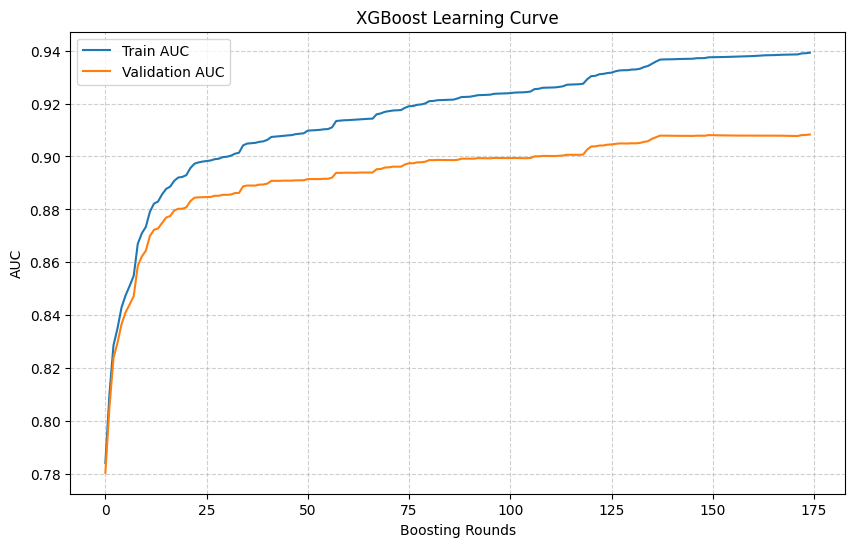

In [ ]:
boosting_rounds = range(len(evals_result["train"]["auc"]))

plt.figure(figsize=(10, 6))

plt.plot(boosting_rounds, evals_result["train"]["auc"], label="Train AUC")

plt.plot(boosting_rounds, evals_result["test"]["auc"], label="Test AUC")

plt.xlabel("Boosting Rounds")
plt.ylabel("AUC")
plt.title("XGBoost Train/Test Learning Curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

The model's validation AUC increases rapidly during the early boosting rounds, then gradually levels off at approximately 0.91. Training AUC continues to increase to about 0.94, creating a widening gap between training and test performance. This suggests increasing overfitting as additional boosting rounds are added, although the test performance remains strong.

### 7. Feature Importance Analysis

Examine XGBoost feature importance to identify the variables contributing most strongly to model predictions.

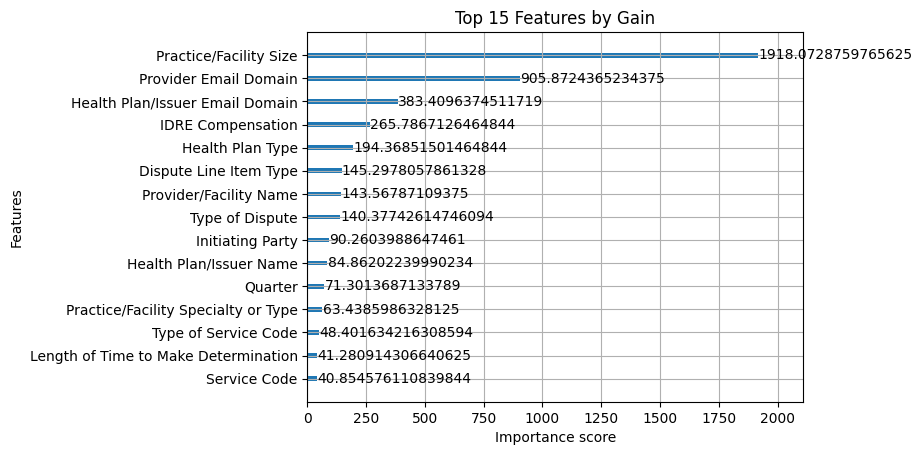

In [10]:
xgb.plot_importance(initial_model, importance_type="gain", max_num_features=15)
plt.title("Top 15 Features by Gain")
plt.show()

We see that the importance score of Practice/Facility Size is more than twice that of the next variable, Provider Email Domain. Because this feature dominates the model, we investigate Practice/Facility Size to further understand how this variable factors into the model's predictions.

### 8. Investigating Practice/Facility Size

Investigate the unexpectedly strong Practice/Facility Size signal to determine what underlying characteristics may explain its importance.

#### 8.1 SHAP analysis of Practice/Facility Size

Use SHAP values to examine how reported and unknown Practice/Facility Size categories contribute to the model's predictions.

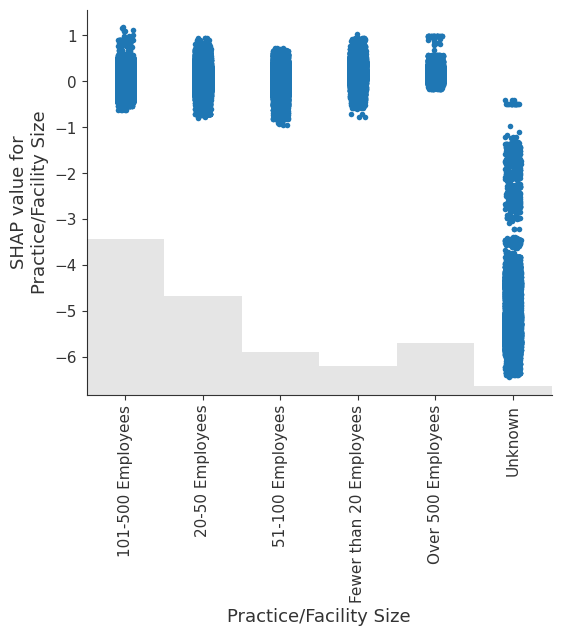

In [11]:
# Create an XGBoost DMatrix with categorical features enabled.
dtrain_shap = xgb.DMatrix(feature_train, enable_categorical=True)

# Create a SHAP TreeExplainer using the initial model.
explainer = shap.TreeExplainer(initial_model)

# Calculate SHAP values for the training data.
shap_values = explainer.shap_values(dtrain_shap)


# Prepare data specifically for SHAP visualization.
clean_data = feature_train.copy()

for column in clean_data.columns:
    if (clean_data[column].dtype == "object" or str(clean_data[column].dtype) == "category"):
        clean_data[column] = clean_data[column].astype("string").fillna("Unknown")
    
# Create SHAP Explanation object.
shap_explanation = shap.Explanation(values=shap_values,
                                    data=clean_data.to_numpy(),
                                    feature_names=clean_data.columns.tolist())

# Plot Practice/Facility Size without SHAP's automatic
# interaction-feature coloring.
shap.plots.scatter(shap_explanation[:, "Practice/Facility Size"], color=None)


Practice/Facility Size was the highest-gain feature in the initial model. This SHAP analysis shows that observations with reported facility-size categories generally make a weak contribution to the outcome, while observations with an unknown facility size produce substantially negative SHAP values. This pattern suggests that the model may be using the presence or absence of facility-size information as an important signal.

The next step is to investigate whether the Unknown category is associated with another variable or decision process that could explain this pattern.

#### 8.2 Default Decision Distribution by Practice/Facility Size

Compare default decision rates across facility-size categories to determine whether missing facility-size information is associated with default decisions.

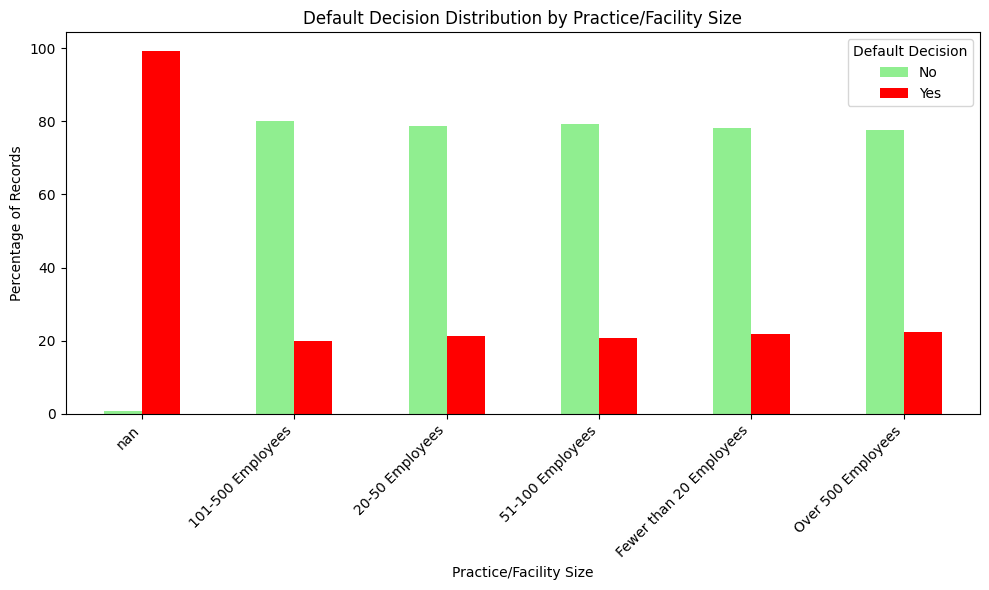

Default decision rates by facility size:
Default Decision            No    Yes
Practice/Facility Size               
NaN                       0.68  99.32
101-500 Employees        80.10  19.90
20-50 Employees          78.74  21.26
51-100 Employees         79.21  20.79
Fewer than 20 Employees  78.06  21.94
Over 500 Employees       77.68  22.32


In [12]:
facility_size_column = "Practice/Facility Size"
default_decision_column = "Default Decision"

facility_default_rates = ( pd.crosstab( idr_data[facility_size_column],
                                        idr_data[default_decision_column],
                                        normalize="index",
                                        dropna=False).mul(100).round(2))

ax = facility_default_rates.plot(kind="bar",
                                 figsize=(10, 6),
                                 color={"No": "lightgreen",
                                        "Yes": "red"})

ax.set_xlabel("Practice/Facility Size")
ax.set_ylabel("Percentage of Records")
ax.set_title("Default Decision Distribution by Practice/Facility Size")
ax.legend(title="Default Decision")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Default decision rates by facility size:")
print(facility_default_rates)

This graph and table show the percentage of default decisions within each Practice/Facility Size category. For disputes with an unknown Practice/Facility Size, decisions were overwhelmingly defaults, with 99.32% being default decisions. Among disputes with a reported Practice/Facility Size, default decisions accounted for approximately 20–22% of cases across all categories. We then examine arbitration outcomes by facility-size to determine whether this pattern is also reflected in observed outcomes.

#### 8.3 Arbitration Outcome Rates by Practice/Facility Size

Compare arbitration outcomes across facility-size categories to determine whether the feature is associated with systematic differences in observed outcomes.

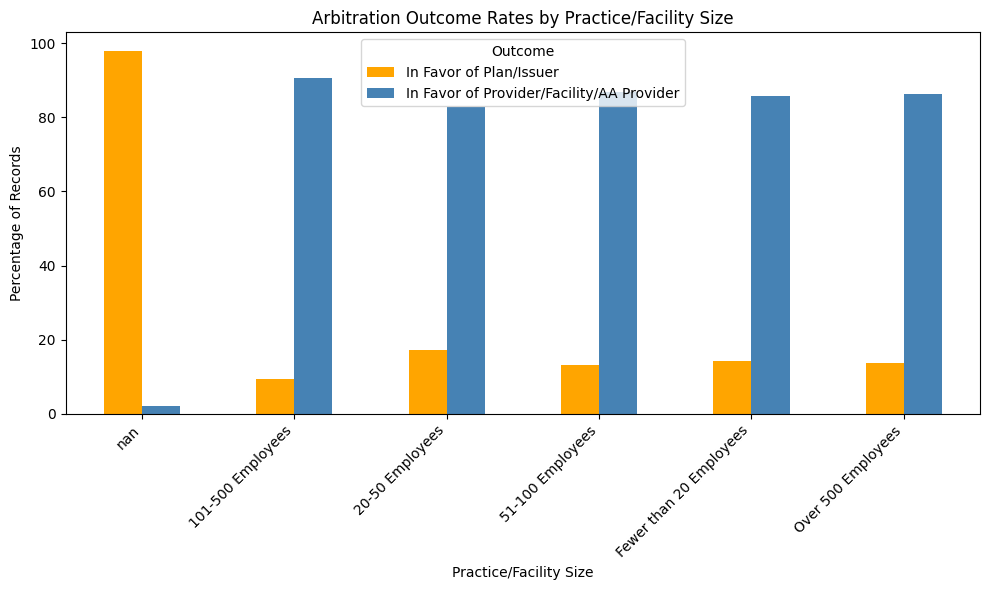


Arbitration outcome rates by facility size:
Offer Selected from Provider or Issuer  In Favor of Plan/Issuer  \
Practice/Facility Size                                            
NaN                                                       97.99   
101-500 Employees                                          9.41   
20-50 Employees                                           17.31   
51-100 Employees                                          13.07   
Fewer than 20 Employees                                   14.28   
Over 500 Employees                                        13.73   

Offer Selected from Provider or Issuer  In Favor of Provider/Facility/AA Provider  
Practice/Facility Size                                                             
NaN                                                                          2.01  
101-500 Employees                                                           90.59  
20-50 Employees                                                             82.69 

In [13]:
facility_outcome_rates = (pd.crosstab(idr_data[facility_size_column],
                                      idr_data[target_column],
                                      normalize="index",
                                      dropna=False).mul(100).round(2))

ax = facility_outcome_rates.plot(kind="bar",
                                 figsize=(10, 6),
                                 color={"In Favor of Plan/Issuer": "orange",
                                        "In Favor of Provider/Facility/AA Provider": "steelblue"})

ax.set_xlabel("Practice/Facility Size")
ax.set_ylabel("Percentage of Records")
ax.set_title("Arbitration Outcome Rates by Practice/Facility Size")
ax.legend(title="Outcome")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nArbitration outcome rates by facility size:")
print(facility_outcome_rates)


This graph and table show the percentage of outcomes within each Practice/Facility Size category. For disputes with an unknown Practice/Facility Size, 97.99% were decided in favor of the plan/health insurer, compared with only 2.01% in favor of the provider/facility. In contrast, among disputes with a reported Practice/Facility Size, provider/facility prevailed in approximately 82.69%–90.59% of cases across the size categories.

The combination of these results with the previous analysis suggests that missing Practice/Facility Size is strongly associated with both default decisions and plan/issuer win outcomes. This provides a plausible explanation for why the initial XGBoost model assigned substantial predictive importance to Practice/Facility Size, particularly the Unknown category.

### 9. Model Refinement

Taken together, these findings indicate that missing Practice/Facility Size is strongly associated with both default decisions and plan/issuer win outcomes. We therefore conduct a second model analysis that excludes default decisions to determine whether the predictive structure observed in the initial model persists among non-default disputes.